In [1]:
!pip install -U pip
!pip install --no-cache-dir --timeout 1000 tensorflow==2.16.2 numpy==1.26.4 scipy==1.12.0 protobuf==4.25.3


In [5]:
from IPython.display import clear_output
clear_output()

In [3]:
!pip install -q tensorflow_quantum==0.7.5

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cirq-ionq 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.3.0 which is incompatible.
cirq-web 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.3.0 which is incompatible.
cirq-pasqal 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.3.0 which is incompatible.
cirq 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.3.0 which is incompatible.
cirq 1.6.1 requires cirq-google==1.6.1, but you have cirq-google 1.3.0 which is incompatible.
cirq-aqt 1.6.1 requires cirq-core==1.6.1, but you have cirq-core 1.3.0 which is incompatible.
dopamine-rl 4.1.2 requires tf-keras>=2.18.0, but you have tf-keras 2.16.0 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have pro

In [4]:
!pip install -q cirq

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-quantum 0.7.5 requires cirq-core==1.3.0, but you have cirq-core 1.6.1 which is incompatible.
tensorflow-quantum 0.7.5 requires cirq-google==1.3.0, but you have cirq-google 1.6.1 which is incompatible.
tensorflow-quantum 0.7.5 requires networkx<3.3, but you have networkx 3.6.1 which is incompatible.
tensorflow-quantum 0.7.5 requires protobuf==4.25.8, but you have protobuf 5.29.6 which is incompatible.
tensorflow 2.16.2 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.6 which is incompatible.
dopamine-rl 4.1.2 requires tf-keras>=2.18.0, but you have tf-keras 2.16.0 which is incompatible.
orbax-checkpoint 0.11.32 requires jax>=0.6.0, but you have jax 0.4.23 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.1

In [2]:
import tensorflow as tf

import numpy as np
from sklearn.model_selection import train_test_split

import tensorflow_quantum as tfq
import cirq
import sympy

from cirq.contrib.svg import SVGCircuit
import matplotlib.pyplot as plt


In [6]:
print("Tensorflow Quantum version == {} ".format(tfq.__version__))
print("Cirq Version == {}".format(cirq.__version__))

Tensorflow Quantum version == 0.7.2 
Cirq Version == 1.3.0


In [7]:
#import the dataset
from tensorflow.keras.datasets import fashion_mnist as dataset

In [8]:
(X_train , y_train) , (X_test , y_test) = dataset.load_data()

4422102/4422102 [==============================] - 0s 0us/step


In [9]:
print("Shape of X_train = {}".format(X_train.shape))
print("Shape of y_train = {}".format(y_train.shape))
print("Shape of X_test = {}".format(X_test.shape))
print("Shape of y_test = {}".format(y_test.shape))

Shape of X_train = (60000, 28, 28)
Shape of y_train = (60000,)
Shape of X_test = (10000, 28, 28)
Shape of y_test = (10000,)


In [10]:
def filter_dataset(x,y):
  keep = (y == 0) |(y == 6)
  x,y = x[keep], y[keep]
  y = y == 5
  return x,y

In [11]:
X_train, y_train = filter_dataset(X_train, y_train)
X_test, y_test = filter_dataset(X_test, y_test)

In [12]:
print("Shape of X_train = {}".format(X_train.shape))
print("Shape of y_train = {}".format(y_train.shape))
print("Shape of X_test = {}".format(X_test.shape))
print("Shape of y_test = {}".format(y_test.shape))

Shape of X_train = (12000, 28, 28)
Shape of y_train = (12000,)
Shape of X_test = (2000, 28, 28)
Shape of y_test = (2000,)


First Image labeled False


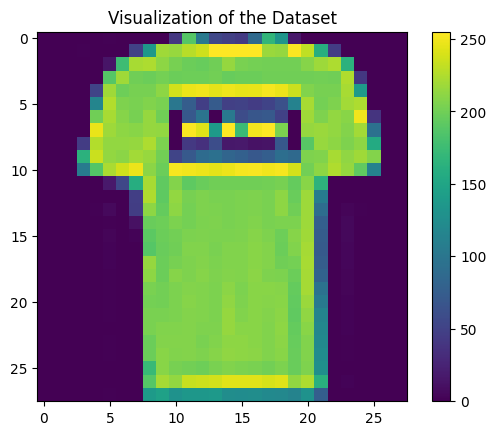

In [13]:
print("First Image labeled {}".format(y_train[0]))
plt.imshow(X_train[0])
plt.colorbar()
plt.title("Visualization of the Dataset")
plt.show()

In [14]:
X_train = X_train/255.0
X_test = X_test/255.0

First Image labeled False


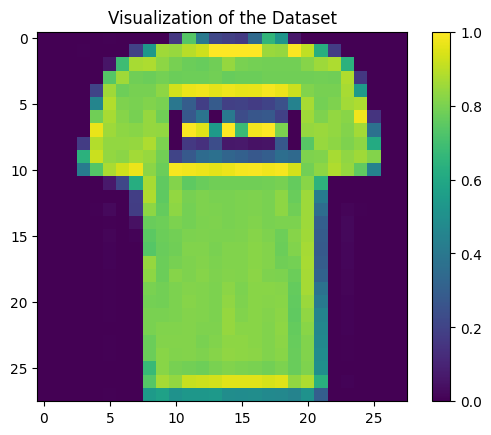

In [15]:
print("First Image labeled {}".format(y_train[0]))
plt.imshow(X_train[0])
plt.colorbar()
plt.title("Visualization of the Dataset")
plt.show()

In [16]:
X_train = X_train.reshape(X_train.shape[0],*(28,28,1))
X_test = X_test.reshape(X_test.shape[0],*(28,28,1))

First Image labeled False


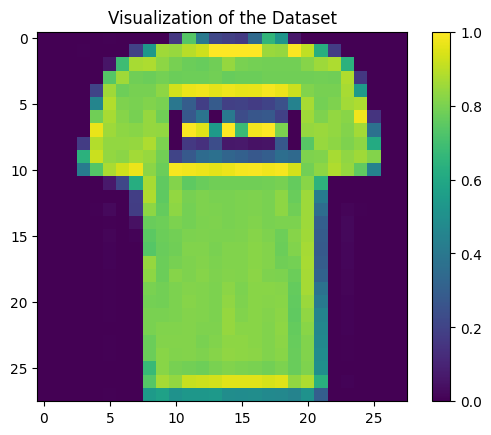

In [17]:
print("First Image labeled {}".format(y_train[0]))
plt.imshow(X_train[0])
plt.colorbar()
plt.title("Visualization of the Dataset")
plt.show()

In [18]:
X_train = tf.image.resize(X_train, (2,2)).numpy()
X_test = tf.image.resize(X_test, (2,2)).numpy()

First Image labeled False


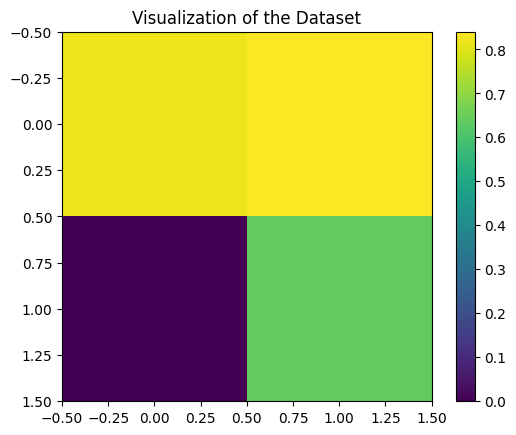

In [19]:
print("First Image labeled {}".format(y_train[0]))
plt.imshow(X_train[0])
plt.colorbar()
plt.title("Visualization of the Dataset")
plt.show()

In [20]:
X_train , X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size = 0.1)

In [21]:
print("Shape of X_train = {}".format(X_train.shape))
print("Shape of y_train = {}".format(y_train.shape))
print("Shape of X_valid = {}".format(X_test.shape))
print("Shape of y_valid = {}".format(y_test.shape))

Shape of X_train = (10800, 2, 2, 1)
Shape of y_train = (10800,)
Shape of X_valid = (2000, 2, 2, 1)
Shape of y_valid = (2000,)


In [22]:
X_train = X_train.reshape(X_train.shape[0],*(1,4,1))
X_valid = X_validation.reshape(X_validation.shape[0],*(1,4,1))
X_test = X_test.reshape(X_test.shape[0],*(1,4,1))

First Image labeled False


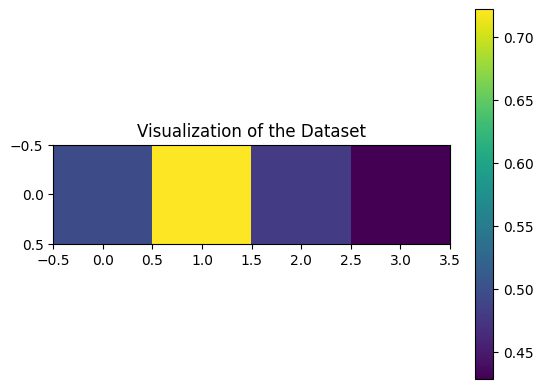

In [23]:
print("First Image labeled {}".format(y_train[0]))
plt.imshow(X_train[0])
plt.colorbar()
plt.title("Visualization of the Dataset")
plt.show()

In [24]:
def binary_encode(X,threshold = 0.5):
  encoded_images = list()
  for image in X:
    encoded_image = [1 if j>threshold else 0 for j in image[0]]
    encoded_images.append(encoded_image)
  return np.array(encoded_images)

In [25]:
X_train = binary_encode(X_train)

In [26]:
X_train[1]

array([1, 1, 0, 1])

In [27]:
def create_circuit_from_image(encoded_image):
  qubits = cirq.GridQubit.rect(2,2)
  circuit = cirq.Circuit() # Initialize the circuit once outside the loop
  for i, pixel in enumerate(encoded_image):
    if pixel:
      circuit.append(cirq.X(qubits[i]))
  return circuit # Return the constructed circuit

In [28]:
import cirq
X_train = [create_circuit_from_image(encoded_image) for encoded_image in X_train]

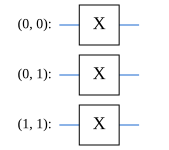

In [30]:
SVGCircuit(X_train[1])

In [31]:
X_train_tfq = tfq.convert_to_tensor(X_train)

In [32]:
X_valid = binary_encode(X_valid)
X_test = binary_encode(X_test)

In [33]:
X_valid = [create_circuit_from_image(encoded_image) for encoded_image in X_valid]
X_test = [create_circuit_from_image(encoded_image) for encoded_image in X_test]


In [34]:
X_valid_tfq = tfq.convert_to_tensor(X_valid)
X_test_tfq = tfq.convert_to_tensor(X_test)

In [35]:
class QNN():
  def __init__(self,data_qubits,readout):
    self.data_qubits = data_qubits
    self.readout = readout
  def add_onequbit_gate(self,circuit,gate,qubit_index):
    for index in qubit_index:
      circuit.append(gate(self.data_qubits[index]))
  def add_twoqubit_gate(self,circuit,gate,qubit_index):
    if len(qubit_index) != 2:
      raise Exception("Two qubit gate requires two qubits")
    circuit.append(gate(self.data_qubits[qubit_index[0]], self.data_qubits[qubit_index[1]]))
  def add_layer(self,circuit,gate,symbol_gate):
    for i, qubit in enumerate(self.data_qubits):
      symbol = sympy.Symbol(symbol_gate + '_' + str(i))
      circuit.append(gate(qubit, self.readout)**symbol)

In [36]:
def create_qnn():
  data_qubits = cirq.GridQubit.rect(2,2)
  readout = cirq.GridQubit(-1,-1)
  circuit = cirq.Circuit()

  circuit.append(cirq.X(readout))
  circuit.append(cirq.H(readout))

  qnn = QNN(data_qubits,readout)
  qnn.add_layer(circuit,cirq.XX,'XX')
  qnn.add_layer(circuit,cirq.ZZ,'ZZ')

  circuit.append(cirq.H(readout))
  return circuit, cirq.Z(readout)

In [37]:
qmodel, model_readout = create_qnn()

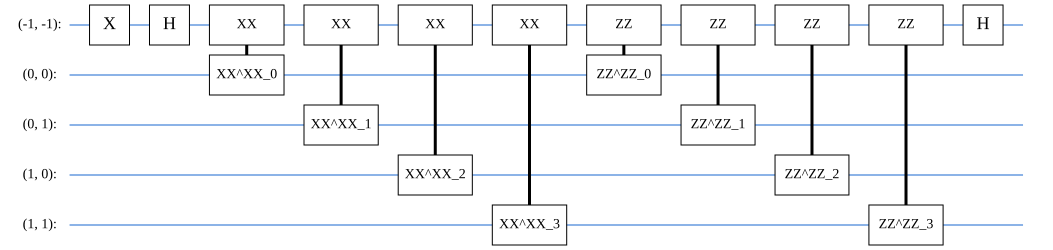

In [38]:
SVGCircuit(qmodel)

In [1]:
!pip uninstall -y tensorflow keras
!pip install tensorflow==2.15.1 tensorflow-quantum

Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: keras 3.8.0
Uninstalling keras-3.8.0:
  Successfully uninstalled keras-3.8.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/

In [39]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    tfq.layers.PQC(qmodel, model_readout)
])


In [42]:
y_train_h = np.array([1 if i == 1 else -1 for i in y_train])
y_valid_h = np.array([1 if i == 1 else -1 for i in y_validation])
y_test_h = np.array([1 if i == 1 else -1 for i in y_test])

In [46]:
print(y_train_h[15])

-1


In [47]:
def hinge_accuracy(y_true, y_pred):
  y_true = tf.squeeze(y_true) > 0.0
  y_pred = tf.squeeze(y_pred) > 0.0
  result = tf.cast(y_true == y_pred, tf.float32)

  return tf.reduce_mean(result)


In [50]:
model.compile(loss = tf.keras.losses.Hinge(),
  optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
  metrics = [hinge_accuracy]
)

In [52]:
qnn_history = model.fit(X_train_tfq,y_train_h,
                        batch_size = 64,
                        epochs = 10,
                        verbose = 1,
                        validation_data = (X_valid_tfq,y_valid_h))

Epoch 1/10
169/169 [==============================] - 11s 54ms/step - loss: 0.6803 - hinge_accuracy: 0.6855 - val_loss: 0.4350 - val_hinge_accuracy: 0.7878
Epoch 2/10
169/169 [==============================] - 10s 60ms/step - loss: 0.3527 - hinge_accuracy: 0.8022 - val_loss: 0.3110 - val_hinge_accuracy: 0.7878
Epoch 3/10
169/169 [==============================] - 10s 60ms/step - loss: 0.2219 - hinge_accuracy: 0.8915 - val_loss: 0.1542 - val_hinge_accuracy: 1.0000
Epoch 4/10
169/169 [==============================] - 9s 54ms/step - loss: 0.0862 - hinge_accuracy: 1.0000 - val_loss: 0.0431 - val_hinge_accuracy: 1.0000
Epoch 5/10
169/169 [==============================] - 11s 66ms/step - loss: 0.0202 - hinge_accuracy: 1.0000 - val_loss: 0.0078 - val_hinge_accuracy: 1.0000
Epoch 6/10
169/169 [==============================] - 11s 64ms/step - loss: 0.0032 - hinge_accuracy: 1.0000 - val_loss: 0.0010 - val_hinge_accuracy: 1.0000
Epoch 7/10
169/169 [==============================] - 11s 66ms/st

In [53]:
model.evaluate(X_test_tfq,y_test_h)

63/63 [==============================] - 1s 17ms/step - loss: 1.5697e-07 - hinge_accuracy: 1.0000


[1.5696883792770677e-07, 1.0]

In [54]:
model.save_weights('content/')